In [1]:
%load_ext autoreload
%autoreload 2

In [41]:
import os
import numpy as np
import uproot
import pandas as pd
from collections import OrderedDict
from common_utils import *
from visualize import *
import fastjet as fj
import awkward as ak
import time
os.environ["HDF5_USE_FILE_LOCKING"] = "FALSE"

In [4]:
ibu_bins = OrderedDict()
ibu_bins["pT_l1"] = np.asarray([25.0, 125.0, 200.0, 300.0, 400.0, 500.0, 800.0])
ibu_bins["pT_l2"] = np.asarray([25.0, 50.0, 75.0, 100.0, 150.0, 200.0, 400.0])
ibu_bins["eta_l1"] = np.asarray([-2.5, -2.0, -1.5, -1.0, -0.75, -0.5, -0.25, 0.0, 0.25, 0.5, 0.75, 1.0, 1.5, 2.0, 2.5])
ibu_bins["eta_l2"] = np.asarray([-2.5, -2.0, -1.5, -1.0, -0.75, -0.5, -0.25, 0.0, 0.25, 0.5, 0.75, 1.0, 1.5, 2.0, 2.5])
ibu_bins["phi_l1"] = np.asarray([-(np.pi + 1e-5), -2.8, -2.4, -2.0, -1.6, -1.2, -0.8, -0.4, 0.0, 0.4, 0.8, 1.2, 1.6, 2.0, 2.4, 2.8, (np.pi + 1e-5)])
ibu_bins["phi_l2"] = np.asarray([-(np.pi + 1e-5), -2.8, -2.4, -2.0, -1.6, -1.2, -0.8, -0.4, 0.0, 0.4, 0.8, 1.2, 1.6, 2.0, 2.4, 2.8, (np.pi + 1e-5)])
ibu_bins["pT_trackj1"] = np.asarray([5.0, 50.0, 100.0, 150.0, 200.0, 300.0, 1000.0])
ibu_bins["pT_trackj2"] = np.asarray([5.0, 25.0, 50.0, 100.0, 500.0])
ibu_bins["y_trackj1"] = np.asarray([-2.5, -2.0, -1.75, -1.5, -1.25, -1.0, -0.75, -0.5, -0.25, 0.0, 0.25, 0.5, 0.75, 1.0, 1.25, 1.5, 1.75, 2.0, 2.5])
ibu_bins["y_trackj2"] = np.asarray([-2.5, -2.0, -1.5, -1.0, -0.5, 0.0, 0.5, 1.0, 1.5, 2.0, 2.5])
ibu_bins["phi_trackj1"] = np.asarray([-(np.pi + 1e-5), -2.8, -2.4, -2.0, -1.6, -1.2, -0.8, -0.4, 0.0, 0.4, 0.8, 1.2, 1.6, 2.0, 2.4, 2.8, (np.pi + 1e-5)])
ibu_bins["phi_trackj2"] = np.asarray([-(np.pi + 1e-5), -2.8, -2.4, -2.0, -1.6, -1.2, -0.8, -0.4, 0.0, 0.4, 0.8, 1.2, 1.6, 2.0, 2.4, 2.8, (np.pi + 1e-5)])
ibu_bins["pT_ll"] = np.asarray([200.0, 230.0, 300.0, 450.0, 600.0, 1000.0])
ibu_bins["y_ll"] = np.asarray([-2.5, -2.0, -1.5, -1.0, -0.75, -0.5, -0.25, 0.0, 0.25, 0.5, 0.75, 1.0, 1.5, 2.0, 2.5])
ibu_bins["Ntracks_trackj1"] = np.asarray([0.5, 6.5, 10.5, 14.5, 19.5, 25.5, 39.5])
ibu_bins["Ntracks_trackj2"] = np.asarray([0.5, 3.5, 7.5, 11.5, 15.5, 34.5])
ibu_bins["m_trackj1"] = np.asarray([0.0, 8.0, 16.0, 24.0, 32.0, 42.0, 70.0])
ibu_bins["m_trackj2"] = np.asarray([0.0, 5.0, 10.0, 20.0, 40.0] )
ibu_bins["tau1_trackj1"] = np.asarray([0.0, 0.05, 0.1, 0.17, 0.25, 0.35, 0.4, 0.9])
ibu_bins["tau1_trackj2"] = np.asarray([0.0, 0.1, 0.2, 0.35, 0.5, 0.9])
ibu_bins["tau2_trackj1"] = np.asarray([0.0, 0.025, 0.05, 0.08, 0.12, 0.17, 0.2, 0.5])
ibu_bins["tau2_trackj2"] = np.asarray([0.0, 0.025, 0.1, 0.17, 0.25, 0.5])
ibu_bins["tau3_trackj1"] = np.asarray([0.0, 0.025, 0.05, 0.1, 0.3])
ibu_bins["tau3_trackj2"] = np.asarray([0.0, 0.025, 0.08, 0.14, 0.3])

#axs[0].set_ylim([0.2,600])

plot_labels = {
    "pT_l1"           : r"Leading lepton $p_{\text{T}}$ [GeV]",
    "pT_l2"           : r"Subleading lepton $p_\text{T}$ [GeV]",
    "eta_l1"          : r"Leading lepton $\eta$",
    "eta_l2"          : r"Subleading lepton $\eta$",
    "phi_l1"          : r"Leading lepton $\phi$",
    "phi_l2"          : r"Subleading lepton $\phi$",
    "pT_trackj1"      : r"Leading jet $p_{\text{T}}$ [GeV]",
    "pT_trackj2"      : r"Subleading jet $p_{\text{T}}$ [GeV]",
    "y_trackj1"       : r"Leading jet $y$",
    "y_trackj2"       : r"Subleading jet $y$",
    "phi_trackj1"     : r"Leading jet $\phi$",
    "phi_trackj2"     : r"Subleading jet $\phi$",
    "pT_ll"           : r"Dilepton $p_{\text{T}}$ [GeV]",
    "y_ll"            : r"Dilepton $y$",
    "Ntracks_trackj1" : r"Leading jet $n_\text{ch}$ ",
    "Ntracks_trackj2" : r"Subleading jet $n_\text{ch}$ ",
    "m_trackj1"       : r"Leading jet $m$ [GeV]",
    "m_trackj2"       : r"Subleading jet $m$ [GeV]",
    "tau1_trackj1"    : r"Leading jet $\tau_1$",
    "tau1_trackj2"    : r"Subleading jet $\tau_1$",
    "tau2_trackj1"    : r"Leading jet $\tau_2$",
    "tau2_trackj2"    : r"Subleading jet $\tau_2$",
    "tau3_trackj1"    : r"Leading jet $\tau_3$",
    "tau3_trackj2"    : r"Subleading jet $\tau_3$",
}

labels = {
     'pT_l1' : r'd$\sigma$/d$p_\text{T}^{\mu 1}$ [fb/GeV]',
     'pT_l2' : r'd$\sigma$/d$p_\text{T}^{\mu 2}$ [fb/GeV]',
     'eta_l1' : r'd$\sigma$/d$\eta^{\mu 1}$ [fb]',
     'eta_l2' : r'd$\sigma$/d$\eta^{\mu 2}$ [fb]',
     'phi_l1' : r'd$\sigma$/d$\phi^{\mu 1}$ [fb]',
     'phi_l2' : r'd$\sigma$/d$\phi^{\mu 2}$ [fb]',
     'pT_trackj1' : r'd$\sigma$/d$p_\text{T}$ [fb/GeV]',
     'pT_trackj2' : r'd$\sigma$/d$p_\text{T}$ [fb/GeV]',
     'y_trackj1' : r'd$\sigma$/d$y$ [fb]',
     'y_trackj2' : r'd$\sigma$/d$y$ [fb]',
     'phi_trackj1' : r'd$\sigma$/d$\phi$ [fb]',
     'phi_trackj2' : r'd$\sigma$/d$\phi$ [fb]',
     'pT_ll' : r'd$\sigma$/d$p_\text{T}^{\mu\mu}$ [fb/GeV]',
     'y_ll' : r'd$\sigma$/d$y^{\mu\mu}$ [fb]',
     'Ntracks_trackj1' : r'd$\sigma$/dn$_\text{ch}$ [fb]',
     'Ntracks_trackj2' : r'd$\sigma$/dn$_\text{ch}$ [fb]',
     'm_trackj1' : r'd$\sigma$/d$m$ [fb/GeV]',
     'm_trackj2' : r'd$\sigma$/d$m$ [fb/GeV]',
     'tau1_trackj1' : r'd$\sigma$/d$\tau_1$ [fb]',
     'tau1_trackj2' : r'd$\sigma$/d$\tau_1$ [fb]',
     'tau2_trackj1' : r'd$\sigma$/d$\tau_2$ [fb]',
     'tau2_trackj2' : r'd$\sigma$/d$\tau_2$ [fb]',
     'tau3_trackj1' : r'd$\sigma$/d$\tau_3$ [fb]',
     'tau3_trackj2' : r'd$\sigma$/d$\tau_3$ [fb]',
 }

var_list = ['pT_l1','pT_l2','eta_l1','eta_l2','phi_l1','phi_l2','pT_trackj1','pT_trackj2','y_trackj1','y_trackj2','phi_trackj1','phi_trackj2','pT_ll','y_ll','Ntracks_trackj1','Ntracks_trackj2','m_trackj1','m_trackj2','tau1_trackj1','tau1_trackj2','tau2_trackj1','tau2_trackj2','tau3_trackj1','tau3_trackj2','tau21','dR_ll']

This notebook will runjet building algorithms to produce unfolded data predictions for various variables build using non-standard jet algorith and jet radii. Possible algorithms includs: Cambridge Achan antikT and kT.  

In [5]:
# Load all event data from ROOT files
f_mg = uproot.open("/Applications/PhD/Omni_Files_Kevin/final_public_data/madgraph_events.root")
t_mg = f_mg["OmniTree"]
truth_pass190 = ak.to_numpy(t_mg["truth_pass190"].array())
truth_pT_ll = ak.to_numpy(t_mg["truth_pT_ll"].array())
truth_pass200 = np.logical_and(truth_pass190, truth_pT_ll > 200)

#madgraph_weights = pd.read_hdf("/Applications/PhD/Omni_Files_Kevin/final_public_data/madgraph_weights.h5")

# f_pseudodata = uproot.open("/Applications/PhD/Omni_Files_Kevin/final_public_data/truth_pseudodata_events.root")
# t_pseudodata = f_pseudodata["OmniTree"]

f_hv = uproot.open("/Applications/PhD/Omni_Files_Kevin/final_public_data/hv_events.root")
t_hv = f_hv["OmniTree"]
truth_pass190_hv = ak.to_numpy(t_hv["truth_pass190"].array())
truth_pT_ll_hv = ak.to_numpy(t_hv["truth_pT_ll"].array())
truth_pass200_hv = np.logical_and(truth_pass190, truth_pT_ll > 200)


f_mg_truth = uproot.open("/Applications/PhD/Omni_Files_Kevin/ZjetOmnifold_4Mar26_MGPy8EGZJetsTruth_SlimedTo10Percent_w_theory.root")
t_mg_truth = f_mg_truth["OmniTree"]
truth_pass190_mg_truth = ak.to_numpy(t_mg_truth["truth_pass190"].array())
truth_pT_ll_mg_truth = ak.to_numpy(t_mg_truth["truth_pT_ll"].array())
truth_pass200_mg_truth = np.logical_and(truth_pass190_mg_truth, truth_pT_ll_mg_truth > 200)


data_weights = pd.read_hdf("/Applications/PhD/Omni_Files_Kevin/final_public_data/data_weights.h5")
weights_omni = data_weights["weights_nominal"]

# f_sherpa1 = uproot.open("/Applications/PhD/Omni_Files_Kevin/final_public_data/sherpa/sherpa_events_part1.root")
# t_sherpa1 = f_sherpa1["OmniTree"]

# f_sherpa2 = uproot.open("/Applications/PhD/Omni_Files_Kevin/final_public_data/sherpa/sherpa_events_part2.root")
# t_sherpa2 = f_sherpa2["OmniTree"]

In [16]:
mapping = {
    "nominal": "weight_mc",
    # "QCD_uu": "QCD_uu",
    # "QCD_un": "QCD_un",
    # "QCD_nu": "QCD_nu",
    # "QCD_nd": "QCD_nd",
    # "QCD_dn": "QCD_dn",
    "QCD_dd": "QCD_dd",
    "PDF_MSHT2020": "PDF_MSHT2020",
    "PDF_CT18nnlo": "PDF_CT18nnlo",
    "*Alpha_s1": "w_Alpha_s1",
    # "Alpha_s2": "w_Alpha_s2",
    "*MPI_down": "w_MPIDown",
    "*MPI_up": "w_MPIUp",
    "*Ren_down": "w_RenDown",
    "*Ren_up": "w_RenUp",
    "*Var1_down": "w_Var1Down",
    "*Var1_up": "w_Var1Up",
    "*Var2_down": "w_Var2Down",
    "*Var2_up": "w_Var2Up",
}

mg_truth_weights = {
    key: np.array(t_mg_truth[branch])[truth_pass200_mg_truth]
    for key, branch in mapping.items()
}

In [10]:
# Load event weights for pseudodata measurement


# sherpa_weights1 = pd.read_hdf("/Applications/PhD/Omni_Files_Kevin/final_public_data/sherpa/sherpa_weights_part1.h5")
# sherpa_weights2 = pd.read_hdf("/Applications/PhD/Omni_Files_Kevin/final_public_data/sherpa/sherpa_weights_part2.h5")

# truth_pseudodata_weights = pd.read_hdf("/Applications/PhD/Omni_Files_Kevin/final_public_data/truth_pseudodata_weights.h5")
#truth_pd_weights = { "truthpd": ak.to_numpy(truth_pseudodata_weights["weight_mc"].array())[truth_pass200_pd == 1]}


# Load event weights for Omnifold data measurement. These get attahed to events in madgraph_events.root
data_weights = pd.read_hdf("/Applications/PhD/Omni_Files_Kevin/final_public_data/data_weights.h5")
data_hv_weights = pd.read_hdf("/Applications/PhD/Omni_Files_Kevin/final_public_data/data_hv_weights.h5")


# # Load all weights from the Omnifold pseudodata measurement.  These get attahed to events in madgraph_events.root
of_pseudodata = pd.read_hdf( "/Applications/PhD/Omni_Files_Kevin/final_public_data/pseudodata_weights.h5", key="weights", mode="r",)
of_pseudodata_hv = pd.read_hdf( "/Applications/PhD/Omni_Files_Kevin/final_public_data/pseudodata_hv_weights.h5", key="hv_weights", mode="r",)


# Create dictionary describing all of the histograms needed for the pseudodata measurement
n_init_weights = [name for name in of_pseudodata.keys() if "weights_ensemble_" in name]
dbootstrap_weights = [name for name in of_pseudodata.keys() if "weights_bootstrap_data_" in name]
mcbootstrap_weights = [name for name in of_pseudodata.keys() if "weights_bootstrap_mc_" in name]
omni_weights = {
    # "prior": madgraph_weights["weights_nominal"][truth_pass200 == 1],
    "nominal": of_pseudodata["weights_nominal"].to_numpy()[truth_pass200 == 1],
    **{f"ensemble_{i}": of_pseudodata[name].to_numpy()[truth_pass200 == 1] for i, name in enumerate(n_init_weights)},
    **{f"bootstrap_data_{i}": of_pseudodata[name].to_numpy()[truth_pass200 == 1] for i, name in enumerate(dbootstrap_weights)},
    **{f"bootstrap_mc_{i}": of_pseudodata[name].to_numpy()[truth_pass200 == 1] for i, name in enumerate(mcbootstrap_weights)},
    "trackEffMain": of_pseudodata["weights_trackEffMain"].to_numpy()[truth_pass200 == 1],
    "trackEffJet": of_pseudodata["weights_trackEffJet"].to_numpy()[truth_pass200 == 1],
    "trackFake": of_pseudodata["weights_trackFake"].to_numpy()[truth_pass200 == 1],
    "trackPtScale": of_pseudodata["weights_trackPtScale"].to_numpy()[truth_pass200 == 1],
    "muCalID": of_pseudodata["weights_muCalID"].to_numpy()[truth_pass200 == 1],
    "muCalMS": of_pseudodata["weights_muCalMS"].to_numpy()[truth_pass200 == 1],
    "muCalResBias": of_pseudodata["weights_muCalResBias"].to_numpy()[truth_pass200 == 1],
    "muCalScale": of_pseudodata["weights_muCalScale"].to_numpy()[truth_pass200 == 1],
    "muEffReco": of_pseudodata["weights_muEffReco"].to_numpy()[truth_pass200 == 1],
    "muEffIso": of_pseudodata["weights_muEffIso"].to_numpy()[truth_pass200 == 1],
    "muEffTrack": of_pseudodata["weights_muEffTrack"].to_numpy()[truth_pass200 == 1],
    "muEffTrig": of_pseudodata["weights_muEffTrig"].to_numpy()[truth_pass200 == 1],
    # "pileup": of_pseudodata["weights_pileup"].to_numpy()[truth_pass200 == 1],
    "lumi": of_pseudodata["weights_lumi"].to_numpy()[truth_pass200 == 1],
    "dd": of_pseudodata["weights_dd"].to_numpy()[truth_pass200 == 1],
    "target_dd": of_pseudodata["target_dd"].to_numpy()[truth_pass200 == 1],
}

# hv_weights = { "hv": of_pseudodata_hv["weights_hv"].to_numpy()[truth_pass200_hv == 1] }

In [38]:

algorithm = fj.antikt_algorithm
R = 0.4
n_jobs = 3
if isinstance(t_mg, list):
    all_kinematics_omni = get_hadron_kinematics(t_mg, get_truth=True, selection = truth_pass200)
    pt_omni             = ak.concatenate([k[0] for k in all_kinematics_omni], axis=0)
    eta_omni            = ak.concatenate([k[1] for k in all_kinematics_omni], axis=0)
    phi_omni            = ak.concatenate([k[2] for k in all_kinematics_omni], axis=0)
    masses_omni         = ak.concatenate([k[3] for k in all_kinematics_omni], axis=0)
else:
    pt_omni, eta_omni, phi_omni, masses_omni = get_hadron_kinematics(t_mg, get_truth=True, selection = truth_pass200)

muon_kinematics_omni = get_muon_kinematics(t_mg, get_truth=True, selection = truth_pass200 )

jets_omni, event_jet_indices_omni = build_jets(
    tree=t_mg,
    pass190_flags=truth_pass200,
    algorithm=algorithm,
    R=R,
    pt=pt_omni,
    eta=eta_omni,
    phi=phi_omni,
    masses=masses_omni,
    n_jobs=n_jobs,
)


Sample kinematics for first event: pt ['43.137352', '39.472950', '34.595486', '26.487041', '23.505688'], eta ['0.300771', '0.315710', '-0.432646', '-1.636316', '0.248256'], phi ['-2.903013', '-2.910223', '2.322683', '3.069867', '-2.967826'], masses ['0.493677', '0.139570', '0.139570', '0.139570', '0.139570']
Preparing 1035714 events for clustering
Processing 1035714 events with 3 jobs


Clustering events:   0%|          | 1010/1035714 [00:00<03:21, 5130.18event/s]

#--------------------------------------------------------------------------
#                         FastJet release 3.5.1#--------------------------------------------------------------------------

#                         FastJet release #                 M. Cacciari, G.P. Salam and G. Soyez                  
3.5.1#     A software package for jet finding and analysis at colliders      
#                           https://fastjet.fr                           
#	                                                                      
# Please cite EPJC72(2012)1896 [arXiv:1111.6097] if you use this package
# for scientific work and optionally PLB641(2006)57 [hep-ph/0512210].   
#                                                                       

#                 M. Cacciari, G.P. Salam and G. Soyez                  
#     A software package for jet finding and analysis at colliders      
#--------------------------------------------------------------------------
#                 

Clustering events: 100%|██████████| 1035714/1035714 [04:20<00:00, 3976.73event/s]


In [39]:
if isinstance(t_mg_truth, list):
    all_kinematics_mg_truth = get_hadron_kinematics(t_mg_truth, get_truth=True, selection = truth_pass200_mg_truth)
    pt_mg_truth             = ak.concatenate([k[0] for k in all_kinematics_mg_truth], axis=0)
    eta_mg_truth            = ak.concatenate([k[1] for k in all_kinematics_mg_truth], axis=0)
    phi_mg_truth            = ak.concatenate([k[2] for k in all_kinematics_mg_truth], axis=0)
    masses_mg_truth         = ak.concatenate([k[3] for k in all_kinematics_mg_truth], axis=0)
else:
    pt_mg_truth, eta_mg_truth, phi_mg_truth, masses_mg_truth = get_hadron_kinematics(t_mg_truth, get_truth=True, selection = truth_pass200_mg_truth)

muon_kinematics_mg_truth = get_muon_kinematics(t_mg_truth, get_truth=True, selection = truth_pass200_mg_truth )

n_jobs = 4
jets_mg_truth, event_jet_indices_mg_truth = build_jets(
    tree=t_mg_truth,
    pass190_flags=truth_pass200_mg_truth,
    algorithm=algorithm,
    R=R,
    pt=pt_mg_truth,
    eta=eta_mg_truth,
    phi=phi_mg_truth,
    masses=masses_mg_truth,
    n_jobs=n_jobs,
)


Sample kinematics for first event: pt ['90.848686', '61.855358', '15.403203', '12.239142', '8.538454'], eta ['1.192918', '1.183475', '0.724462', '1.475351', '0.702464'], phi ['-2.525083', '-2.511176', '0.470192', '-2.491172', '0.479485'], masses ['0.139570', '0.139570', '0.139570', '0.000511', '0.139570']
Preparing 1982505 events for clustering
Processing 1982505 events with 4 jobs


Clustering events:   0%|          | 822/1982505 [00:00<06:53, 4797.73event/s]

#--------------------------------------------------------------------------
#                         FastJet release 3.5.1#--------------------------------------------------------------------------
#                         FastJet release 3.5.1

#                 M. Cacciari, G.P. Salam and G. Soyez                  
#                 M. Cacciari, G.P. Salam and G. Soyez                  
#     A software package for jet finding and analysis at colliders      
#     A software package for jet finding and analysis at colliders      
#                           https://fastjet.fr                           
#                           https://fastjet.fr                           
#	                                                                      
#	                                                                      
# Please cite EPJC72(2012)1896 [arXiv:1111.6097] if you use this package
# Please cite EPJC72(2012)1896 [arXiv:1111.6097] if you use this package
# for scientific wor

Clustering events: 100%|██████████| 1982505/1982505 [07:54<00:00, 4179.61event/s] 


In [86]:

print(len(jets_mg_truth))
print(len(mg_truth_weights["nominal"]))

r_edges    = np.array([0,0.025,0.05,0.075,0.1,0.125,0.15,0.175,0.2,0.225,0.25,0.275,0.3,0.325,0.35,0.375,0.4])
bin_widths = np.diff(r_edges)
r_centers  = 0.5 * (r_edges[:-1] + r_edges[1:])
# radial_prof_omni_1  = jet_radial_profile(
#     jets              = jets_omni,
#     event_jet_indices = event_jet_indices_omni,
#     track_pt          = pt_omni, track_eta=eta_omni, track_phi=phi_omni, track_mass=masses_omni,
#     annulus_edges     = r_edges,
#     event_weights     = [weights_omni],
#     only_associated   = True,
#     jet_pt_range      = np.array([150,160]),
#     jet_y_max         = 2,
#     use_rho_old       = False,
#     compute_psi       = False,
#     only_leading_jet  = True,
#     max_events        = 100000,
# )
# print("Omni radial profile computed\n")

radial_prof_omni      = jet_radial_profile_mod(
    jets              = jets_omni,
    event_jet_indices = event_jet_indices_omni,
    track_pt          = pt_omni, track_eta=eta_omni, track_phi=phi_omni, track_mass=masses_omni,
    annulus_edges     = r_edges,
    weights_dict      = omni_weights,
    only_associated   = True,
    jet_pt_range      = np.array([30,40]),
    jet_y_max         = 2,
    use_rho_old       = False,
    compute_psi       = False,
    only_leading_jet  = True,
    max_events        = 50000,
)

print("Omni radial profile computed\n")
radial_prof_mg_truth  = jet_radial_profile_mod(
    jets              = jets_mg_truth,
    event_jet_indices = event_jet_indices_mg_truth,
    track_pt          = pt_mg_truth, track_eta=eta_mg_truth, track_phi=phi_mg_truth, track_mass=masses_mg_truth,
    annulus_edges     = r_edges,
    weights_dict      = mg_truth_weights,
    only_associated   = True,
    jet_pt_range      = np.array([30,40]),
    jet_y_max         = 2,
    use_rho_old       = False,
    compute_psi       = False,
    only_leading_jet  = True,
    max_events        = 50000,
)
print("MG truth radial profile computed")

1982505
1982505
10% complete (5000/50000 events)
20% complete (10000/50000 events)
30% complete (15001/50000 events)
40% complete (20000/50000 events)
50% complete (25000/50000 events)
60% complete (30000/50000 events)
70% complete (35000/50000 events)
80% complete (40000/50000 events)
89% complete (45000/50000 events)
99% complete (50000/50000 events)
Omni radial profile computed

10% complete (5000/50000 events)
20% complete (10000/50000 events)
30% complete (15001/50000 events)
40% complete (20000/50000 events)
50% complete (25000/50000 events)
60% complete (30000/50000 events)
70% complete (35000/50000 events)
80% complete (40000/50000 events)
89% complete (45000/50000 events)
99% complete (50000/50000 events)
MG truth radial profile computed


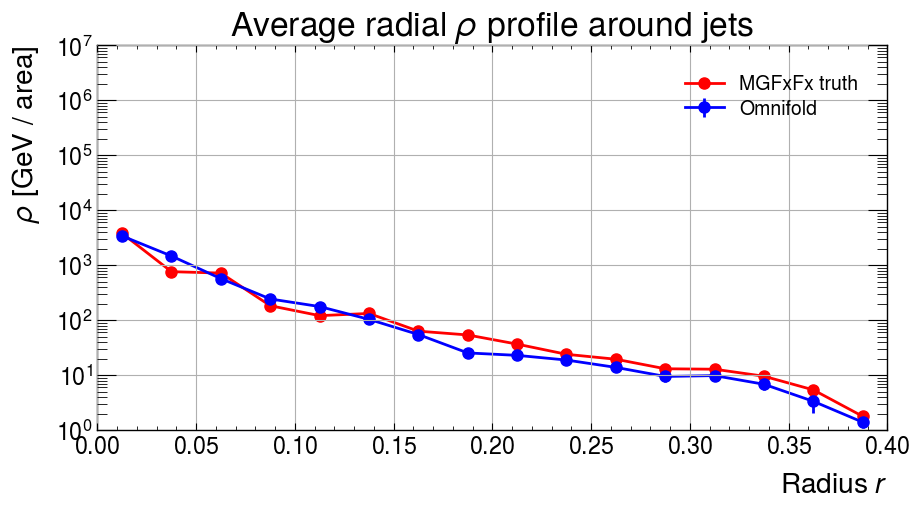

In [87]:
import matplotlib.pyplot as plt
# Create figure
plt.figure(figsize=(10,5))


# Plot rho
# plt.plot(r_centers, radial_prof_omni[0], marker='o', linestyle='-', color='blue', label=r'Omnifold')
plt.errorbar(r_centers, radial_prof_omni[0], yerr=radial_prof_omni[1], marker='o', linestyle='-', color='blue', label=r'Omnifold')
plt.plot(r_centers, radial_prof_mg_truth[0], marker='o', linestyle='-', color='red', label=r'MGFxFx truth')
plt.xlabel("Radius $r$")
plt.ylabel(r"$\rho$ [GeV / area]")
plt.ylim(1,10e6)
plt.title("Average radial $\\rho$ profile around jets")
plt.grid(True)
plt.yscale("log")
plt.legend()

plt.show()

In [46]:
def individual_jet_selection(pt, y, phi, m):
    return (pt > 10) & (abs(y) < 2)

# omni weights are pre- divided by 140.1, so we need to multiply by that to get the correct normalization for the count
nJets_omni        = count_jets(jets_omni, weights_omni, individual_jet_selection) * 140.1
nLeadingJets_omni = count_jets(jets_omni, weights_omni, individual_jet_selection, leading_jet_only = True) * 140.1
print(nJets_omni, nLeadingJets_omni)


nJets_mg_truth = count_jets(jets_mg_truth, mg_truth_weights["nominal"], individual_jet_selection) 
nLeadingJets_mg_truth = count_jets(jets_mg_truth, mg_truth_weights["nominal"], individual_jet_selection, leading_jet_only = True)
print(nJets_mg_truth, nLeadingJets_mg_truth)



580419.144145443 229120.59404388434
566212.8291461744 219898.84375


In [48]:
expr_list = [
    "m_trackj1",
    "pT_trackj1",
    "m_trackj1/pT_trackj1",
]
start_time = time.time()
jet_obs_omni = eval_jet_expressions(jets_omni, expr_list, nevents=-1)
elapsed = time.time() - start_time
print(f"Total runtime: {elapsed:.2f} seconds")
print("First event:", jet_obs_omni[0])

start_time = time.time()
jet_obs_mg_truth = eval_jet_expressions(jets_mg_truth, expr_list, nevents=-1)
start_time = time.time()
print("First event MG truth:", jet_obs_mg_truth[0])

Processing expressions:m_trackj1, pT_trackj1, m_trackj1/pT_trackj1 for 1035714 events
Extracting jet info for tokens: m_trackj1, pT_trackj1
Processed 1035714/1035714 events (100%)
Finished extracting jet info for all tokens.
Evaluating 3 expressions for 1035714 events...
Processed 1/3 expressions (33%)
Processed 2/3 expressions (67%)
Processed 3/3 expressions (100%)
Finished evaluating all expressions.
Total runtime: 156.74 seconds
First event: [3.14395985e+01 1.83058596e+02 1.71746092e-01]
Processing expressions:m_trackj1, pT_trackj1, m_trackj1/pT_trackj1 for 1982505 events
Extracting jet info for tokens: m_trackj1, pT_trackj1
Processed 1982505/1982505 events (100%)
Finished extracting jet info for all tokens.
Evaluating 3 expressions for 1982505 events...
Processed 1/3 expressions (33%)
Processed 2/3 expressions (67%)
Processed 3/3 expressions (100%)
Finished evaluating all expressions.
First event MG truth: [2.05149655e+01 2.03935618e+02 1.00595304e-01]


In [55]:
import numpy as np
import awkward as ak

def hist_with_uncertainty(data, bins, obs, weights_dict):
    """hist_with_uncertainty - Computes histograms and associated uncertainties for multiple observables.

    Arguments:
    data - (ak.Array or np.ndarray) array of shape (N, M) where M is number of observables
    bins - (dict) bin edges keyed by observable name
    obs - (list of str) observable names corresponding to columns in data
    weights_dict - (dict) dictionary of weight arrays. Keys can include:
                   "nominal" for nominal weights,
                   "ensemble_*", "bootstrap_mc_*", "bootstrap_data_*" for replica uncertainties,
                   other keys for systematic variations.
                   If a key starts with "*", the weight is treated as multiplicative
                   and applied as nominal * weight.

    Returns:
    (dict) - mapping {obs_name: (hist, unc)} where:
             hist is the nominal histogram,
             unc is the total uncertainty per bin
    """

    results = {}

    for idx in range(len(obs)):
        data_obs  = data[:, idx]
        binning   = bins[obs[idx]]
        nominal_w = weights_dict["nominal"]

        # Identify weight groups
        ensemble = [k for k in weights_dict if k.startswith("ensemble_")]
        bootstrap_mc = [k for k in weights_dict if k.startswith("bootstrap_mc_")]
        bootstrap_data = [k for k in weights_dict if k.startswith("bootstrap_data_")]

        special = set(["nominal"] + ensemble + bootstrap_mc + bootstrap_data)
        syst_weights = [k for k in weights_dict if k not in special]

        # Nominal histogram
        hist_nom, _ = np.histogram(data_obs, bins=binning, weights=nominal_w)
        unc2 = np.zeros_like(hist_nom, dtype=float)

        # --- Systematic uncertainties ---
        for name in syst_weights:
            w = weights_dict[name]

            # Handle multiplicative systematics (prefix "*")
            if name.startswith("*"):
                w_eff = nominal_w * w
            else:
                w_eff = w

            hist_var, _ = np.histogram(data_obs, bins=binning, weights=w_eff)
            unc2 += (hist_nom - hist_var) ** 2

        # --- Replica uncertainties ---
        def replica_unc(keys):
            if not keys:
                return np.zeros_like(hist_nom, dtype=float)

            hists = []
            for k in keys:
                w = weights_dict[k]
                hist, _ = np.histogram(data_obs, bins=binning, weights=w)
                hists.append(hist)

            return np.std(np.stack(hists), axis=0) ** 2

        unc2 += replica_unc(ensemble)
        unc2 += replica_unc(bootstrap_mc)
        unc2 += replica_unc(bootstrap_data)

        results[obs[idx]] = (hist_nom, np.sqrt(unc2))

    return results

In [56]:

nom_omni_results = hist_with_uncertainty(
    data=jet_obs_omni,     # dict-like or dataframe containing variables
    weights_dict=omni_weights,
    obs = ["m_trackj1"],
    bins=ibu_bins,
)

nom_mg_truth_results = hist_with_uncertainty(
    data=jet_obs_mg_truth,     # dict-like or dataframe containing variables
    weights_dict=mg_truth_weights,
    obs = ["m_trackj1"],
    bins=ibu_bins,
)


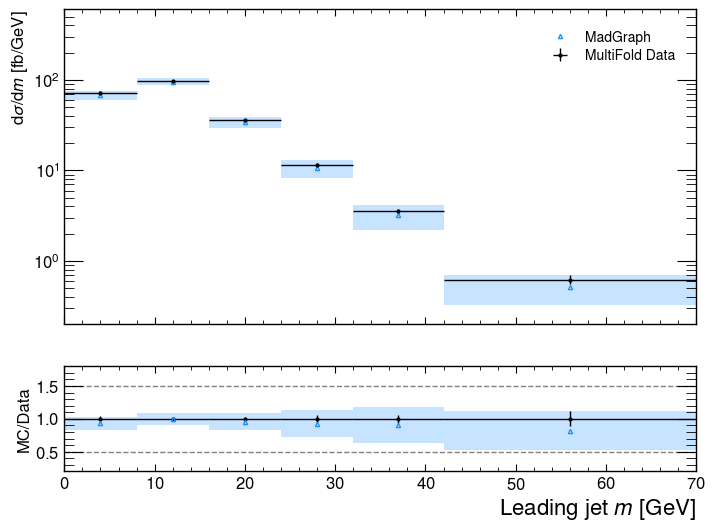

In [80]:
#fig = plt.figure(figsize=(15,20), dpi=300, constrained_layout=True)
hist_params_OmniFold = {
    "color": "black",
    "linewidth": 2,
    "density": True,
    "alpha": 0
}

lumi = 140.1
fig, axs = plt.subplots(2, 1, sharex=True, sharey=False, gridspec_kw = {'height_ratios':[3, 1]})
var = expr_list[0]
bins = ibu_bins[var]
bin_centers = 0.5 * (bins[1:] + bins[:-1])
bin_widths = np.array([bins[n+1] - bins[n] for n in range(len(bins)-1)])

# if "trackj1" in var: 
#     df = multifold[mask_trackj1]
# elif "trackj2" in var:
#     df = multifold[mask_trackj2]
# else:
#     df = multifold    

### Sherpa
# counts = mc_preds[i]['sherpa_counts']
# sherpa_density = counts/lumi/bin_widths
# sherpa_error = mc_preds[i]['sherpa_err']/mc_preds[i]['sherpa_counts']
# _ = make_error_boxes(axs[0], bin_centers, sherpa_density, np.vstack([bin_widths/2,bin_widths/2]), np.vstack([sherpa_density*sherpa_error, sherpa_density*sherpa_error]), facecolor='deeppink', alpha=0.25, marker="s", label=r'Sherpa',)

### MGFxFx 
counts = nom_mg_truth_results[var][0]
mgfxfx_density = counts/lumi/bin_widths
mgfxfx_error = nom_mg_truth_results[var][1]/nom_mg_truth_results[var][0]
_ = make_error_boxes(axs[0], bin_centers, mgfxfx_density, np.vstack([bin_widths/2,bin_widths/2]), np.vstack([mgfxfx_density*mgfxfx_error, mgfxfx_density*mgfxfx_error]), facecolor='dodgerblue', alpha=0.25, marker="^", label=r'MadGraph')

### OmniFold
omni_density = nom_omni_results[var][0]/bin_widths
omni_error   = nom_omni_results[var][1]/bin_widths
omni_plot    = axs[0].hist(omni_density,  align='mid', **hist_params_OmniFold)

axs[0].minorticks_on()
axs[1].minorticks_on()
axs[0].xaxis.set_tick_params(labelsize=12, which='both', direction='in', top=True)
axs[0].yaxis.set_tick_params(labelsize=12, which='both', direction='in', right=True)
axs[0].set_ylabel(labels[var], fontsize=12, labelpad=2, loc='top')
#axs[0].set_ylim([0, 1.7 * max(max(mgfxfx_density), max(omni_density))])

### Set some plots to use log y scale
# if 'phi' not in var and 'eta' not in var and 'y' not in var:
#     axs[0].set_yscale('log')
#     axs[0].set_ylim([0.5*min(min(sherpa_density), min(omni_density)), 10 * max(max(sherpa_density), max(omni_density))])

# elif 'phi' in var:
#     axs[0].set_ylim(0,600)

axs[0].errorbar(bin_centers, omni_density, xerr=bin_widths/2, yerr=omni_error, marker=".", linestyle="None", color="k", alpha=1, ecolor='k', label="MultiFold Data", markersize=4, linewidth=1)
axs[0].legend(fontsize=10, frameon=False, loc='best')
axs[0].set_yscale('log')
axs[1].errorbar(bin_centers, np.ones(len(bin_centers)), xerr=bin_widths/2, yerr=omni_error/omni_density, marker=".", linestyle="None", color="k", alpha=1,  ecolor='k', label="MultiFold Data", markersize=4, linewidth=1)
# _ = make_error_boxes(axs[1], bin_centers, sherpa_density/omni_density, np.vstack([bin_widths/2,bin_widths/2]), np.vstack([(sherpa_density/omni_density)*sherpa_error, (sherpa_density/omni_density)*sherpa_error]), facecolor='deeppink', alpha=0.25, marker="s", label=r'Sherpa')
_ = make_error_boxes(axs[1], bin_centers, mgfxfx_density/omni_density, np.vstack([bin_widths/2,bin_widths/2]), np.vstack([(mgfxfx_density/omni_density)*mgfxfx_error, (mgfxfx_density/omni_density)*mgfxfx_error]), facecolor='dodgerblue', alpha=0.25, marker="^", label=r'MGFxFx')
axs[1].set_xlim(bins[0], bins[-1])
axs[1].set_ylim([0.2,1.8])
axs[1].xaxis.set_tick_params(labelsize=12, which='both', direction='in', top=True)
axs[1].yaxis.set_tick_params(labelsize=12, which='both', direction='in', right=True)
axs[1].set_ylabel('MC/Data', fontsize=12, labelpad=2, loc='center')
axs[1].set_xlabel(plot_labels[var], fontsize=16, labelpad=2, loc='right')
axs[1].axhline(0.5, color='gray', linestyle='--', linewidth=1)
axs[1].axhline(1.5, color='gray', linestyle='--', linewidth=1)
  

In [ ]:
fig = plt.figure(figsize=(22,11), dpi=300, constrained_layout=True)
subfigs = fig.subfigures(4, 6)

for i, subfig in enumerate(subfigs.flat):
    ax = subfig.subplots(1, 1)
    colors = [plt.cm.Paired(i) for i in range(20)]
    var = list(bins_dict.items())[i][0]
    bins = np.array(list(bins_dict.items())[i][1])

    ax.step(bins, np.concatenate([[uncertainties[var+'_exp'][0]],uncertainties[var+'_exp']]),              label = "Experimental",       color=colors[0],    )
    ax.step(bins, np.concatenate([[uncertainties[var+'_theory'][0]],uncertainties[var+'_theory']]),        label = "Theory",             color=colors[1],    )
    ax.step(bins, np.concatenate([[uncertainties[var+'_mc_stat'][0]],uncertainties[var+'_mc_stat']]),      label = "MC Stat. + NN",      color=colors[2],    )
    ax.step(bins, np.concatenate([[uncertainties[var+'_data_stat'][0]],uncertainties[var+'_data_stat']]),  label = "Data Stat.",         color=colors[3],    )
    ax.step(bins, np.concatenate([[uncertainties[var+'_unfolding'][0]],uncertainties[var+'_unfolding']]),  label = "Unfolding",          color=colors[4]     )
    ax.step(bins, np.concatenate([[uncertainties[var+'_top'][0]],uncertainties[var+'_top']]),              label = "Top",                color=colors[5],    )
    ax.step(bins, np.concatenate([[uncertainties[var+'_nonDY'][0]],uncertainties[var+'_nonDY']]),          label = r"EW $Zjj$ + $ZV$",   color=colors[6],    )
    ax.step(bins, np.concatenate([[uncertainties[var+'_total'][0]],uncertainties[var+'_total']]),          label = "Total",              color='black',      )

    ### draw lines at the beginning and end of the first and last bins, for plotting purposes
    label_list = ['exp', 'theory', 'mc_stat', 'data_stat', 'unfolding', 'top', 'nonDY', 'total']
    for label in label_list:
        plt.vlines(x=bins[0], ymin=0, ymax=uncertainties[var+'_'+label][0])
        plt.vlines(x=bins[-1], ymin=0, ymax=uncertainties[var+'_'+label][-1])

    ax.xaxis.set_tick_params(labelsize=12)
    ax.yaxis.set_tick_params(labelsize=12)
    if i % 6 == 0: ax.set_ylabel("Fractional Uncertainty [\%]", fontsize=12)
    ax.legend(fontsize=9, loc='upper left', ncol=2, frameon=False)
    ax.set_xlim([bins[0], bins[-1]])
    ax.set_ylim([0, 25])
    ax.set_xlabel(plot_labels[var], fontsize=14);
    
plt.savefig(os.path.join(plot_dir,"total_systs.pdf"))